In [1]:
import anndata as ad
import pandas as pd
import numpy as np
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
# import random
from scipy.stats import norm
from CME_func import *
import numba
from numba import cuda, njit, prange, float32
from p_value import *
import time


/home/shadeform/anaconda3/envs/FAST_CME/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [2]:
adata = sc.read_h5ad('../sim_data/adata/adata_16.h5ad')

In [29]:
@cuda.jit(device=True, inline=True)
def gpu_shuffle_row(row, n_cols, rng_states, thread_id):
    """
    Fisher-Yates shuffle for a single row on GPU.
    """
    for i in range(n_cols - 1, 0, -1):
        r = xoroshiro128p_uniform_float32(rng_states, thread_id)
        j = int(r * (i + 1))
        if j != i:
            tmp = row[i]
            row[i] = row[j]
            row[j] = tmp


@cuda.jit
def shuffle_kernel(d_X, rng_states, n_rows, n_cols):
    """
    每行一个线程块: shuffle + 按列归一化
    等价于 Python: X_shuffled = X_shuffled.T / X_shuffled.T.sum(axis=1)[None, :] * 1e4
    """
    tid = cuda.blockIdx.x * cuda.blockDim.x + cuda.threadIdx.x
    if tid >= n_rows:
        return

    # 当前行
    row = d_X[tid]

    # 1. Shuffle 每行
    gpu_shuffle_row(row, n_cols, rng_states, tid)

@cuda.jit
def normalize_kernel(d_X, n_rows, n_cols):
    """
    对 device 上的矩阵 d_X 进行按列归一化
    等价于: X = X.T / X.T.sum(axis=1)[None, :] * 1e4
    """
    # 每个线程负责一列中的一部分
    col = cuda.blockIdx.x
    thread_id = cuda.threadIdx.x
    stride = cuda.blockDim.x

    # Step 1. 每列先计算总和 (分块累加 + 原子操作)
    sum_val = 0.0
    for row in range(thread_id, n_rows, stride):
        sum_val += d_X[row, col]

    # 使用共享内存做块内归约
    smem = cuda.shared.array(256, dtype=np.float32)  # 假设线程数 ≤ 256
    smem[thread_id] = sum_val
    cuda.syncthreads()

    # 并行归约
    offset = stride // 2
    while offset > 0:
        if thread_id < offset:
            smem[thread_id] += smem[thread_id + offset]
        offset //= 2
        cuda.syncthreads()

    # 最终每列的和由线程 0 保留
    col_sum = smem[0]
    cuda.syncthreads()

    # Step 2. 归一化
    if col_sum > 0.0:
        scale = 1e4 / col_sum
        for row in range(thread_id, n_rows, stride):
            d_X[row, col] *= scale


def CME_correction(X: np.ndarray, cme: np.ndarray, iterations=50,
                   normalize=True, tp_cutoff=0.95, fp_cutoff=0.05, gpu=True):
    n_rows, n_cols = X.shape

    # CPU 输出缓存
    null_CME_list = []

    # 线程配置
    threads_per_block = 256
    blocks_per_grid = (n_rows + threads_per_block - 1) // threads_per_block

    # 为所有行分配 RNG 状态
    rng_states = create_xoroshiro128p_states(n_rows, seed=42)

    for it in range(iterations):
        # --- Step 1: 复制 X 到 GPU ---
        d_X = cuda.to_device(X.astype(np.float32))

        # --- Step 2: GPU Shuffle + 按列归一化 ---
        shuffle_kernel[blocks_per_grid, threads_per_block](
            d_X, rng_states, n_rows, n_cols
        )
        cuda.synchronize()

        n_rows, n_cols = d_X.shape
        # 每列一个 block，每列内部使用 256 个线程
        threads_per_block_norm = 256
        blocks_per_grid_norm = n_cols

        normalize_kernel[blocks_per_grid_norm, threads_per_block_norm](d_X, n_rows, n_cols)
        cuda.synchronize()

        # --- Step 3: 计算 CME (直接在 GPU 上) ---
        cme_shuffled = CME(d_X, normalize=normalize, gpu=True)
        null_CME_list.append(cme_shuffled)

        # --- Step 5: 清理显存 ---
        del d_X
        cuda.current_context().deallocations.clear()

    # Stack 成 numpy array
    null_CME = np.array(null_CME_list)

    # === CME rank correction ===
    cme_rank = np.mean(null_CME < cme[np.newaxis, :, :], axis=0)

    cme_corrected = cme.copy()
    cme_corrected[cme_rank < fp_cutoff] = 0
    cme_corrected[(cme_rank >= fp_cutoff) & (cme_rank <= tp_cutoff)] = 0.2

    return cme_corrected


In [3]:
sc.pp.normalize_total(adata, target_sum=1e4)

In [15]:
res_cme = CME(adata.X.T.astype(np.float32), gpu=True)

In [16]:
start = time.time()
new = CME_correction(adata.X.T.astype(np.float32), res_cme)
end = time.time()
print(end-start)

/home/shadeform/anaconda3/envs/FAST_CME/lib/python3.9/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 5 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


4.893415689468384


<Axes: >

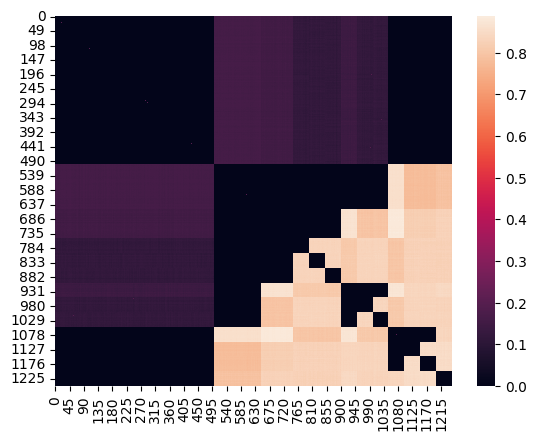

In [17]:
sns.heatmap(new)

<Axes: >

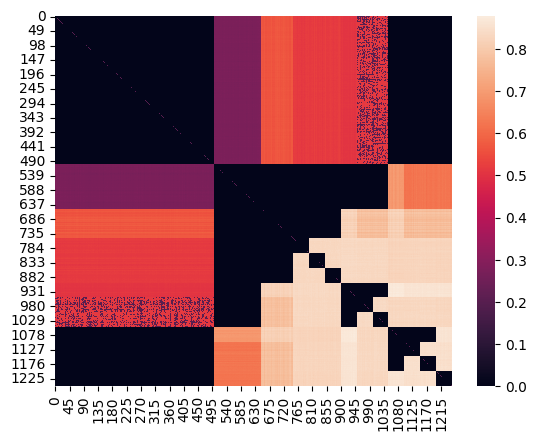

In [32]:
sns.heatmap(new)

In [10]:
@cuda.jit
def sum_normalize_kernel(d_X, n_rows, n_cols):
    """
    对每行按和归一化: X[row, col] = X[row, col] / sum(row)
    """
    row = cuda.blockIdx.x  # 每个 block 处理一行
    tid = cuda.threadIdx.x

    # 1. 并行计算每行的和
    partial_sum = cuda.shared.array(256, dtype=np.float32)  # 假设线程数 <= 256
    local_sum = 0.0

    # 每个线程累加一部分
    for col in range(tid, n_cols, cuda.blockDim.x):
        local_sum += d_X[row, col]
    partial_sum[tid] = local_sum
    cuda.syncthreads()

    # 2. 线程间做归约求和（Reduction）
    step = cuda.blockDim.x // 2
    while step > 0:
        if tid < step:
            partial_sum[tid] += partial_sum[tid + step]
        step //= 2
        cuda.syncthreads()

    # 3. 按和归一化
    total_sum = partial_sum[0]
    total_sum /= 1e4 
    if total_sum > 0:
        for col in range(tid, n_cols, cuda.blockDim.x):
            d_X[row, col] /= total_sum


In [14]:
X = adata.X.T.astype(np.float32)

In [15]:
median_ary = np.apply_along_axis(
    lambda v: np.sum(v[np.nonzero(v)]), 1, X
)
X_normed = X / median_ary[:, None]
print(X_normed*1e4)

[[0.10453007 2.012204   0.36585528 ... 0.9407706  0.810108   0.4181203 ]
 [0.39124447 1.2258993  0.756406   ... 1.1998163  0.8868208  0.46949336]
 [0.28711256 1.7487766  0.28711256 ... 0.8091354  0.96574223 0.6525285 ]
 ...
 [0.         0.26471132 0.         ... 6.7501388  3.8383145  1.985335  ]
 [0.         0.         0.         ... 6.545639   5.744132   2.9388585 ]
 [0.         1.3472004  0.13472004 ... 7.948483   3.9068816  2.829121  ]]


In [16]:
d_X = cuda.to_device(X)
n_rows = d_X.shape[0]
n_cols = d_X.shape[1]

threads_per_block = 256
blocks_per_grid = n_rows  # 每行一个 block

# 选择按和归一化
sum_normalize_kernel[blocks_per_grid, threads_per_block](d_X, n_rows, n_cols)
cuda.synchronize()

# 或者选择按均值归一化
# mean_normalize_kernel[blocks_per_grid, threads_per_block](d_X, n_rows, n_cols)
# cuda.synchronize()

# 拷贝回 CPU
X_normalized = d_X.copy_to_host()

# 拷贝结果回 CPU
X_normed = d_X.copy_to_host()

In [11]:
res_cme = CME(adata.X.T, normalize=True, feature_indices=None, gpu=True)

In [ ]:
# 可调整：共享数组的最大长度（必须 >= threads_per_block）
SHARED_BLOCK = 256

# device helper: 标准正态 cdf（device 可调用）
@cuda.jit(device=True, inline=True)
def norm_cdf_cuda(x):
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

# ---------------------------------------------------------
# GPU kernel: 每个 block 处理一个 (i,j) pair（对称上三角或全体 pair）
# blockDim.x = threads_per_block
# gridDim.x = total_pairs  (total_pairs = feature_size * (feature_size + 1) // 2)
# 输入：
#   X: (num_rows, n)  float32  -- expression matrix（行 = features）
#   CME_matrix: full CME matrix (num_rows, num_rows) float32
#   feature_indices: 1D int32 array length feature_size (映射到行索引)
#   p_value_mtx: device array (feature_size, feature_size) float32  (写回)
#   n: number of columns (cells)
#   feature_size, total_pairs: ints
# 说明：block 内用 shared arrays 暂存每个 thread 的 partial sums，再由 thread0 汇总并写回 p_value。
# ---------------------------------------------------------
@cuda.jit
def p_value_sym_gpu_kernel(X, CME_matrix, feature_indices, p_value_mtx, n, feature_size, total_pairs):
    idx = cuda.blockIdx.x               # 当前 pair 的线性索引（0..total_pairs-1）
    t = cuda.threadIdx.x
    T = cuda.blockDim.x                 # threads per block

    # 如果超过上限就退出
    if idx >= total_pairs:
        return

    # ===== map linear idx -> (i, j) on upper-triangle (0<=i<=j<feature_size) =====
    # 使用简单循环映射（feature_size 通常不会非常大）
    i = 0
    count = idx
    while count >= (feature_size - i):
        count -= (feature_size - i)
        i += 1
    j = i + count

    # 实际的行索引（指向 X 的行）
    xi = feature_indices[i]
    yj = feature_indices[j]

    # 局部累加器（每个 thread 的局部值）
    s1_local = 0.0         # S1 = sum_{p,q} m
    s2_local = 0.0         # S2 = sum_{p,q} m^2
    row_sq_local = 0.0     # sum_p (row_p)^2
    col_sq_local = 0.0     # sum_q (col_q)^2
    sumX_local = 0.0       # sum of X[xi, :]
    sumY_local = 0.0       # sum of X[yj, :]

    # ----- 每个 thread 负责 p 的子集，计算 row_p、sum_m2_p -----
    pidx = t
    while pidx < n:
        ap = float(X[xi, pidx])   # X[xi, p]
        row_p = 0.0
        sum_m2_p = 0.0
        qidx = 0
        # 遍历所有 q 来计算 row_p 和该行的 m^2 和
        while qidx < n:
            bp = float(X[yj, qidx])
            m = ap if ap < bp else bp
            row_p += m
            sum_m2_p += m * m
            qidx += 1
        s1_local += row_p
        s2_local += sum_m2_p
        row_sq_local += row_p * row_p
        sumX_local += ap
        pidx += T

    # ----- 每个 thread 负责 q 的子集，计算 col_q -----
    qidx = t
    while qidx < n:
        bq = float(X[yj, qidx])
        col_q = 0.0
        p2 = 0
        # 遍历所有 p 来计算 col_q
        while p2 < n:
            ap2 = float(X[xi, p2])
            m2 = ap2 if ap2 < bq else bq
            col_q += m2
            p2 += 1
        col_sq_local += col_q * col_q
        sumY_local += bq
        qidx += T

    # ===== block 内 reduction：把每个 thread 的 partial 写到 shared，然后 thread0 做汇总 =====
    # 注意：SHARED_BLOCK 必须 >= T
    sh_s1 = cuda.shared.array((SHARED_BLOCK,), dtype=float32)
    sh_s2 = cuda.shared.array((SHARED_BLOCK,), dtype=float32)
    sh_row_sq = cuda.shared.array((SHARED_BLOCK,), dtype=float32)
    sh_col_sq = cuda.shared.array((SHARED_BLOCK,), dtype=float32)
    sh_sumX = cuda.shared.array((SHARED_BLOCK,), dtype=float32)
    sh_sumY = cuda.shared.array((SHARED_BLOCK,), dtype=float32)

    # 存入 shared
    sh_s1[t] = s1_local
    sh_s2[t] = s2_local
    sh_row_sq[t] = row_sq_local
    sh_col_sq[t] = col_sq_local
    sh_sumX[t] = sumX_local
    sh_sumY[t] = sumY_local

    cuda.syncthreads()

    # thread 0 在 block 内做串行汇总（简单可靠）
    if t == 0:
        s1 = 0.0
        s2 = 0.0
        sum_row_sq = 0.0
        sum_col_sq = 0.0
        sumX = 0.0
        sumY = 0.0
        # 只累加到实际线程数 T
        for k in range(T):
            s1 += float(sh_s1[k])
            s2 += float(sh_s2[k])
            sum_row_sq += float(sh_row_sq[k])
            sum_col_sq += float(sh_col_sq[k])
            sumX += float(sh_sumX[k])
            sumY += float(sh_sumY[k])
        
        
        # 计算 ES, VarS 等
        n_f = float(n)
        ES = s1 / n_f
        term1 = s2 / n_f
        part4 = s1 * s1 - sum_row_sq - sum_col_sq + s2
        # 避免 n*(n-1) 为 0
        if n > 1:
            term2 = part4 / (n_f * (n_f - 1.0))
        else:
            term2 = 0.0
        VarS = term1 + term2 - ES * ES

        # 归一化（sumX = sum(X[xi,:]), sumY = sum(X[yj,:])）
        min_sum = sumX if sumX < sumY else sumY
        if min_sum <= 0.0 or VarS <= 0.0:
            # 若无法计算方差或归一化（分母为0），返回中性 p-value（可按需改）
            p_val = 0.5
        else:
            ES = ES / min_sum
            VarS = VarS / (min_sum * min_sum)
            if VarS <= 0.0:
                p_val = 0.5
            else:
                CME_val = float(CME_matrix[xi, yj])
                z = (1.0 - CME_val - ES) / math.sqrt(VarS)
                p_val = norm_cdf_cuda(z)

        # 写回 p_value_mtx（对称）
        p_value_mtx[i, j] = p_val
        p_value_mtx[j, i] = p_val


In [73]:
def p_value_sym_cuda(X, CME_matrix, feature_indices=None, threads_per_block=128):
    """
    GPU 上计算对称 p_value 矩阵（整个流程在 GPU 上完成，host 只做调度与拷回）
    注意：threads_per_block 必须 <= SHARED_BLOCK
    """
    assert threads_per_block <= SHARED_BLOCK, "threads_per_block must be <= SHARED_BLOCK"

    # feature_indices
    if feature_indices is None:
        feature_indices = np.arange(X.shape[0], dtype=np.int32)
    else:
        feature_indices = feature_indices.astype(np.int32)

    feature_size = feature_indices.shape[0]
    total_pairs = feature_size * (feature_size + 1) // 2
    n = X.shape[1]

    # device 转移（float32）
    X_device = cuda.to_device(X.astype(np.float32))
    CME_device = cuda.to_device(CME_matrix.astype(np.float32))
    feature_indices_device = cuda.to_device(feature_indices)
    p_value_mtx_device = cuda.device_array((feature_size, feature_size), dtype=np.float32)

    # 启动 kernel：每个 block 处理一个 pair
    blocks_per_grid = int(total_pairs)
    threads = int(threads_per_block)

    p_value_sym_gpu_kernel[blocks_per_grid, threads](
        X_device, CME_device, feature_indices_device, p_value_mtx_device,
        n, feature_size, total_pairs
    )
    cuda.synchronize()

    # 拷回 host
    p_value_mtx = p_value_mtx_device.copy_to_host()
    return p_value_mtx


In [67]:
median_ary = np.apply_along_axis(lambda v: np.median(v[np.nonzero(v)]), 1, adata.X.T)
X_normed = adata.X.T / median_ary[:, None]

In [74]:
res_p = p_value_sym_cuda(adata.X.T, res_cme)

<Axes: >

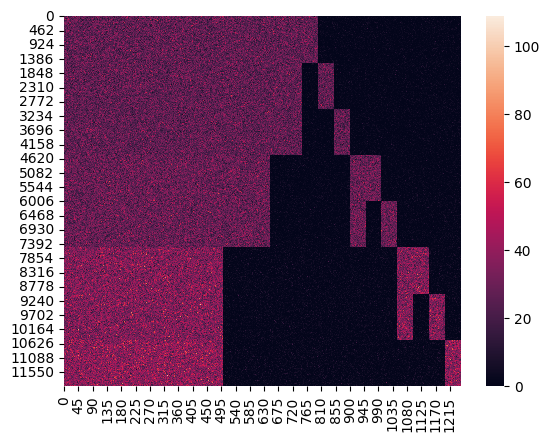

In [60]:
sns.heatmap(adata.X)

<Axes: >

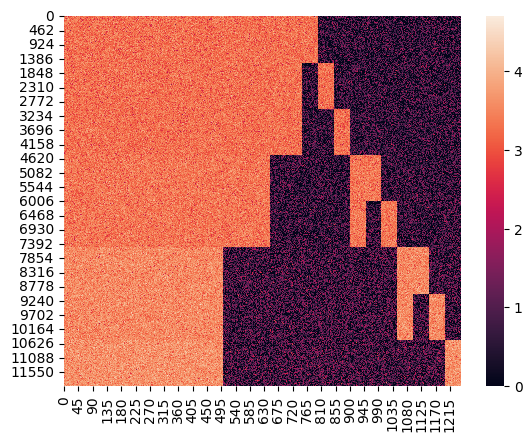

In [59]:
sns.heatmap(np.log(adata.X+1))

<Axes: >

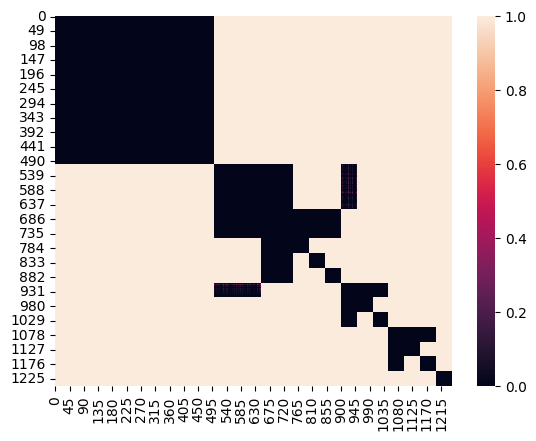

In [75]:
sns.heatmap(1-res_p)

<Axes: >

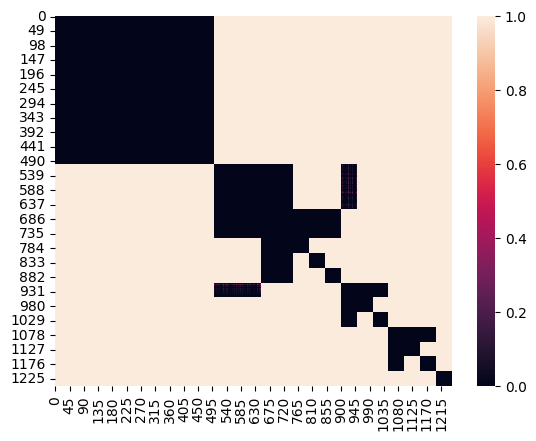

In [71]:
sns.heatmap(1-res_p)

<Axes: >

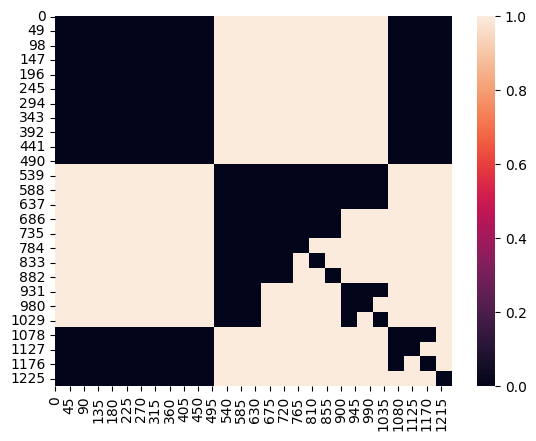

In [61]:
sns.heatmap(1-res_p)

<Axes: >

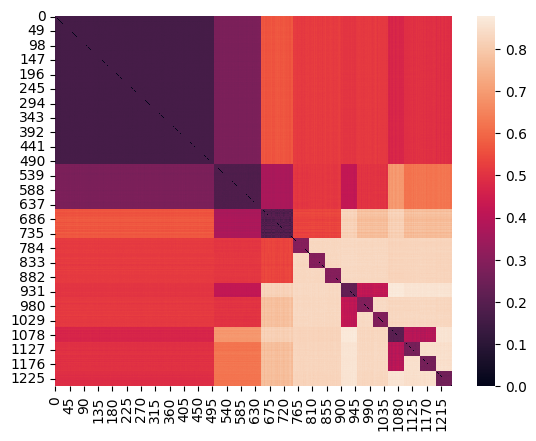

In [66]:
sns.heatmap(res_cme)

In [97]:
def compute_p_value(X, i, j, CME_value):
    n = len(X[i,:])

    M = outer_minimum(X[i,:], X[j,:])
    
    # E[S]
    ES = M.sum() / n
    
    # 第一部分: E[m_{i,pi(i)}^2]
    s1 = np.sum(M ** 2) 
    term1 = s1 / n
    
    # 第二部分: 计算交叉项
    total_sum = np.sum(M)  
    row_sums = np.sum(M, axis=1) 
    col_sums = np.sum(M, axis=0)  
    sum_row_sq = np.sum(row_sums ** 2) 
    sum_col_sq = np.sum(col_sums ** 2)  
    

    part4 = total_sum ** 2 - sum_row_sq - sum_col_sq + s1
    term2 = part4 / (n * (n - 1))
    
    VarS = term1 + term2 - ES**2

    sumx = np.sum(X[i,:])
    sumy = np.sum(X[j,:])

    print(ES)
    print(np.sqrt(VarS))
    print((1-CME_value)*min(sumx,sumy))
    
    z = ((1-CME_value)*min(sumx,sumy) - ES) / (math.sqrt(VarS)) # N(0,1)
    print(z)
    p_value = norm_cdf(z)
    return p_value

In [100]:
probability = compute_p_value(np.sqrt(adata.X.T), 148, 149, res_cme[148,149])
print(probability)

58067.266
42.33202
61264.8494130831
75.5358169603549
1.0


In [42]:
def compute_CME_test(x,y):
    min_ary = np.minimum(x, y)
    min_sum = min_ary.sum()
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    ratio_x = min_sum / sum_x
    ratio_y = min_sum / sum_y

    cme = 1 - max(ratio_x, ratio_y)

    return cme

In [ ]:
x = adata.X.T[148,:]
y = adata.X.T[149,:]

In [92]:
compute_CME_test(adata.X.T[148,:],adata.X.T[149,:])

np.float64(0.1582246792531553)

In [91]:
compute_CME_test(np.sqrt(adata.X.T[148,:]),np.sqrt(adata.X.T[149,:]))

np.float64(0.08144180319344785)

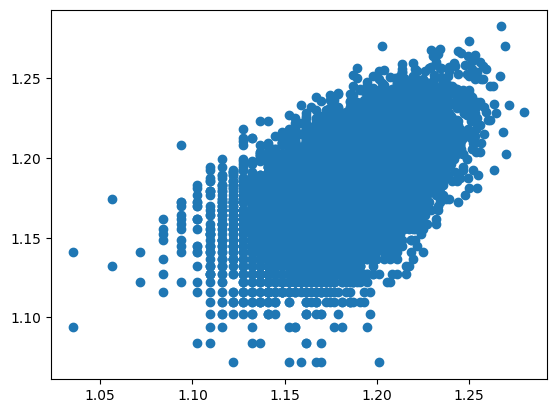

In [105]:
plt.scatter(x**0.05, y**0.05)

In [101]:
x = adata.X.T[148,:]
y = adata.X.T[149,:]

cme__ = []
for i in range(0,10000):
    y_shuffled = np.random.permutation(y)

    cme__.append(compute_CME_test(x**0.05,y_shuffled**0.05))

In [102]:
np.mean(cme__)

np.float64(0.012517035912879703)

In [103]:
np.var(cme__)

np.float64(4.120038772572594e-09)

<Axes: ylabel='Count'>

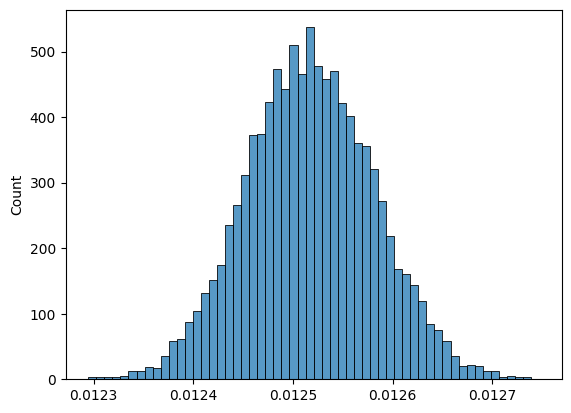

In [104]:
sns.histplot(cme__)

In [ ]:
X = cuda.to_device(adata.X.T)